# ⭐ Day 63: Advanced Model Evaluation & Ensembling Techniques
### *Building More Reliable & Powerful Models*
---
**Day 63 of 369-day Python & AI Learning Path** 🐍🤖


## 🎯 Welcome to Day 63!
Welcome back, learner! By now, you've built a solid foundation in machine learning — from data preprocessing to training your first models. But here's the truth: **good models don't win competitions; reliable and well-ensembled models do.**
Today, we take a giant leap forward. We're moving beyond simple train-test splits and basic accuracy scores. You'll master the art of rigorously evaluating your models and then combining them into intelligent ensembles that consistently outperform any single model.
Ensembling isn't just a trick for Kaggle competitions; it's a cornerstone of production-grade machine learning systems. Whether you're predicting customer churn, forecasting sales, or diagnosing diseases, the techniques you'll learn today will make your models more robust, generalizable, and trustworthy.
By the end of this notebook, you'll understand *why* models fail, *how* to diagnose their weaknesses using advanced visualizations, and *how* to fix them using powerful techniques like Voting, Stacking, and Blending. Let's build models that not only perform well on paper but also thrive in the real world! 🚀


## 📋 Table of Contents
1. [Advanced Cross-Validation Strategies](#1-advanced-cross-validation-strategies)
2. [Comprehensive Model Evaluation Metrics](#2-comprehensive-model-evaluation-metrics)
3. [Learning Curves & Validation Curves](#3-learning-curves--validation-curves)
4. [Introduction to Ensemble Methods](#4-introduction-to-ensemble-methods)
5. [Voting Ensembles](#5-voting-ensembles)
6. [Stacking & Blending Techniques](#6-stacking--blending-techniques)
7. [Applying Ensembling to Titanic Dataset](#7-applying-ensembling-to-titanic-dataset)
8. [Applying Ensembling to House Prices Dataset](#8-applying-ensembling-to-house-prices-dataset)
9. [Performance Comparison](#9-performance-comparison)
10. [Best Practices for Ensembling](#10-best-practices-for-ensembling-in-real-projects)
11. [Hands-On Exercises](#-hands-on-exercises)
12. [Solutions & Best Practices](#-solutions--best-practices)


## 1. Advanced Cross-Validation Strategies
Cross-validation is the backbone of reliable model evaluation. Basic K-Fold is a start, but real-world data is messy. Let's explore strategies for imbalanced, grouped, and temporal data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression, fetch_openml
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, GroupKFold, TimeSeriesSplit,
    cross_val_score, train_test_split, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, 
    StackingClassifier, RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, mean_squared_error, r2_score,
    mean_absolute_error
)
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# Generate synthetic data for CV demonstrations
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                           n_redundant=5, n_classes=2, weights=[0.9, 0.1], 
                           random_state=42)
groups = np.random.randint(0, 50, size=1000)
print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Number of groups: {len(np.unique(groups))}")


Dataset shape: (1000, 20)
Class distribution: [892 108]
Number of groups: 50


In [3]:
# Compare different CV strategies
model = LogisticRegression(max_iter=1000, random_state=42)
cv_strategies = {
    'K-Fold (5)': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'RepeatedStratifiedKFold (5x3)': RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    'GroupKFold (5)': GroupKFold(n_splits=5)
}
results = {}
for name, cv in cv_strategies.items():
    if 'Group' in name:
        scores = cross_val_score(model, X, y, cv=cv, groups=groups, scoring='roc_auc')
    else:
        scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    results[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")
print("\n💡 Repeated CV reduces variance in your score estimates!")


K-Fold (5): 0.8551 (+/- 0.0529)
RepeatedStratifiedKFold (5x3): 0.8473 (+/- 0.0611)
GroupKFold (5): 0.8589 (+/- 0.0327)

💡 Repeated CV reduces variance in your score estimates!


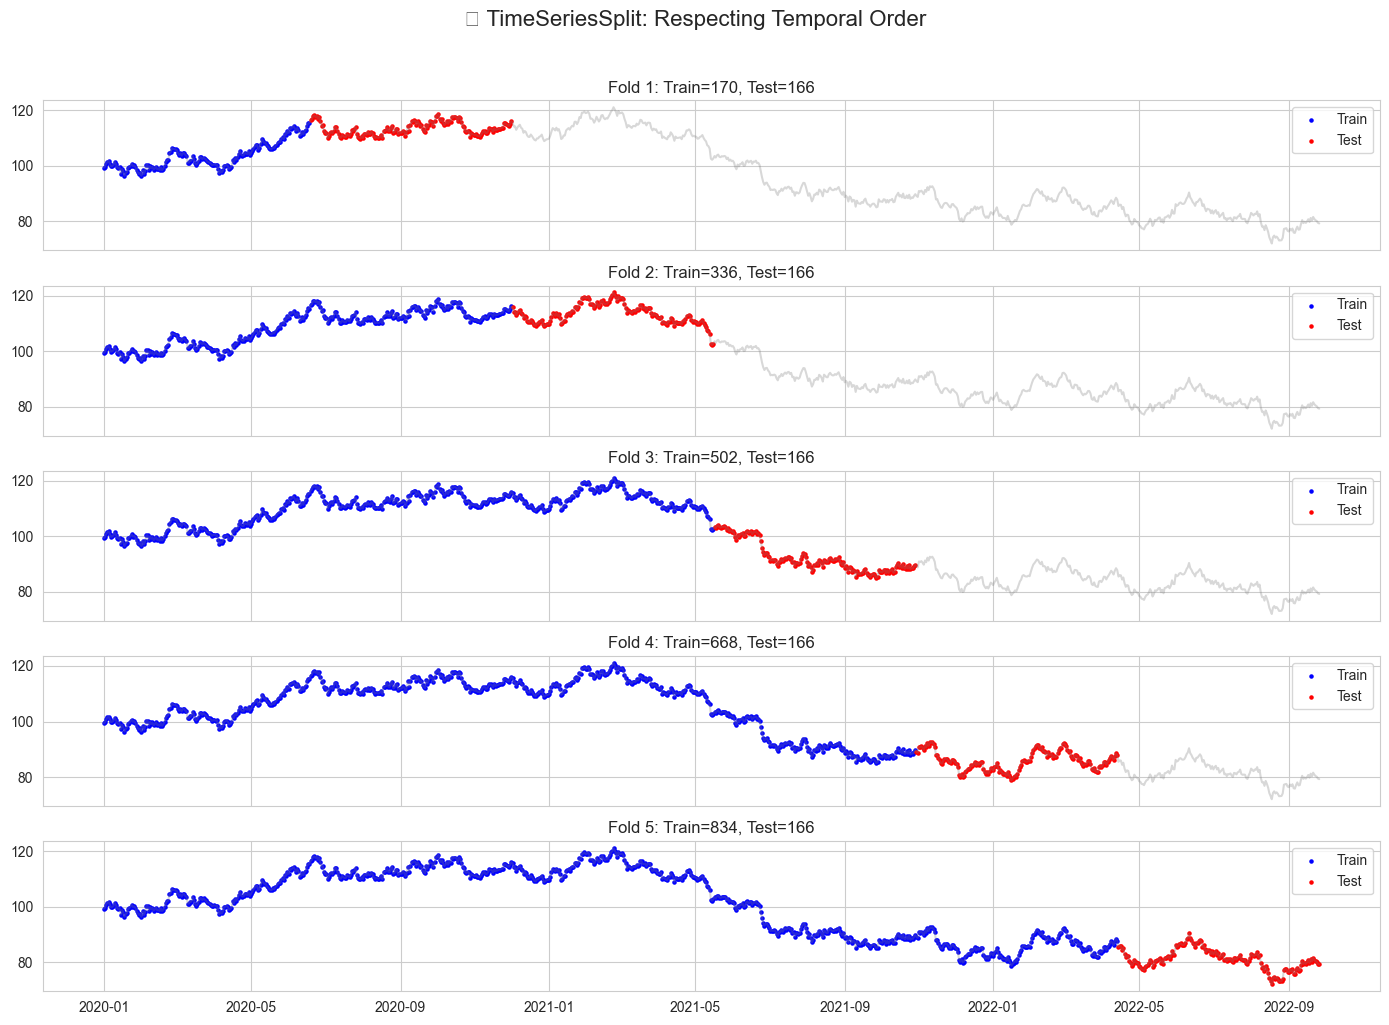

In [4]:
# TimeSeriesSplit demonstration
dates = pd.date_range('2020-01-01', periods=1000, freq='D')
ts_data = pd.DataFrame({'value': np.cumsum(np.random.randn(1000)) + 100, 'date': dates})
tscv = TimeSeriesSplit(n_splits=5)
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
for i, (train_idx, test_idx) in enumerate(tscv.split(ts_data)):
    axes[i].plot(ts_data['date'], ts_data['value'], alpha=0.3, color='gray')
    axes[i].scatter(ts_data['date'].iloc[train_idx], ts_data['value'].iloc[train_idx], 
                    c='blue', s=5, label='Train')
    axes[i].scatter(ts_data['date'].iloc[test_idx], ts_data['value'].iloc[test_idx], 
                    c='red', s=5, label='Test')
    axes[i].set_title(f'Fold {i+1}: Train={len(train_idx)}, Test={len(test_idx)}')
    axes[i].legend()
plt.suptitle('🔄 TimeSeriesSplit: Respecting Temporal Order', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 2. Comprehensive Model Evaluation Metrics & Interpretation
Accuracy alone is misleading, especially with imbalanced data. Let's explore the full spectrum of evaluation metrics and how to interpret them. 📊


In [5]:
# Generate imbalanced dataset for metric demonstration
X_eval, y_eval = make_classification(n_samples=2000, n_features=15, weights=[0.85, 0.15], 
                                     random_state=42, flip_y=0.1)
X_train, X_test, y_train, y_test = train_test_split(X_eval, y_eval, test_size=0.3, 
                                                    random_state=42, stratify=y_eval)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]


In [6]:
# Comprehensive metrics report
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}
print("📈 Comprehensive Evaluation Metrics:\n")
for metric, value in metrics.items():
    print(f"   {metric:12s}: {value:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))


📈 Comprehensive Evaluation Metrics:

   Accuracy    : 0.9100
   Precision   : 0.8085
   Recall      : 0.6786
   F1-Score    : 0.7379
   ROC-AUC     : 0.8674

              precision    recall  f1-score   support

     Class 0       0.93      0.96      0.95       488
     Class 1       0.81      0.68      0.74       112

    accuracy                           0.91       600
   macro avg       0.87      0.82      0.84       600
weighted avg       0.91      0.91      0.91       600



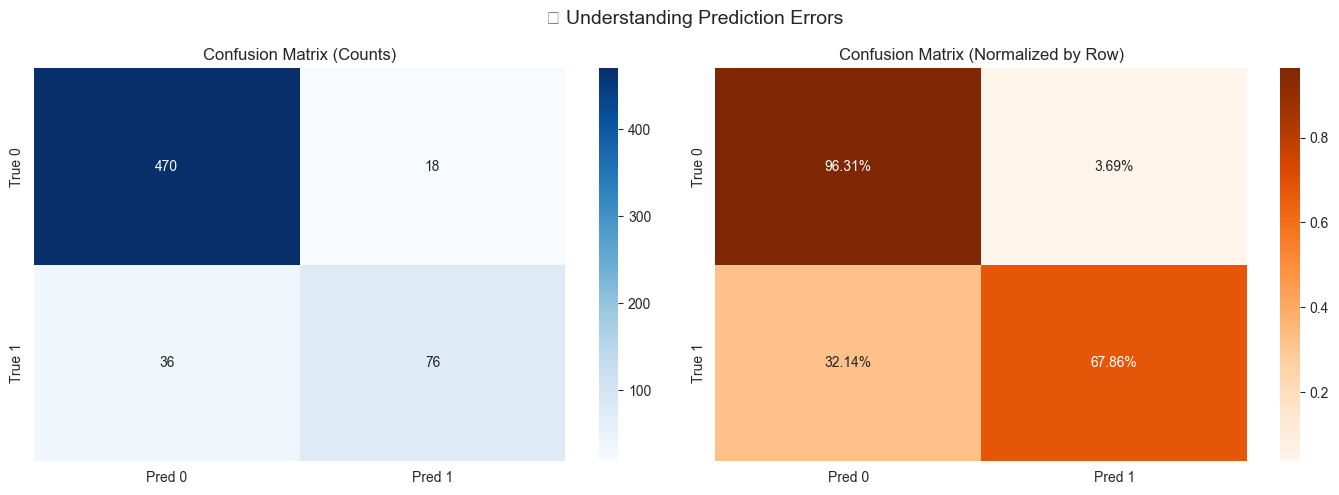

In [7]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], 
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
ax[0].set_title('Confusion Matrix (Counts)')
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=ax[1],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
ax[1].set_title('Confusion Matrix (Normalized by Row)')
plt.suptitle('🧩 Understanding Prediction Errors', fontsize=14)
plt.tight_layout()
plt.show()


## 3. Learning Curves & Validation Curves for Diagnosing Bias/Variance
These curves are your diagnostic toolkit. They tell you whether you need more data, more complexity, or regularization. 💡


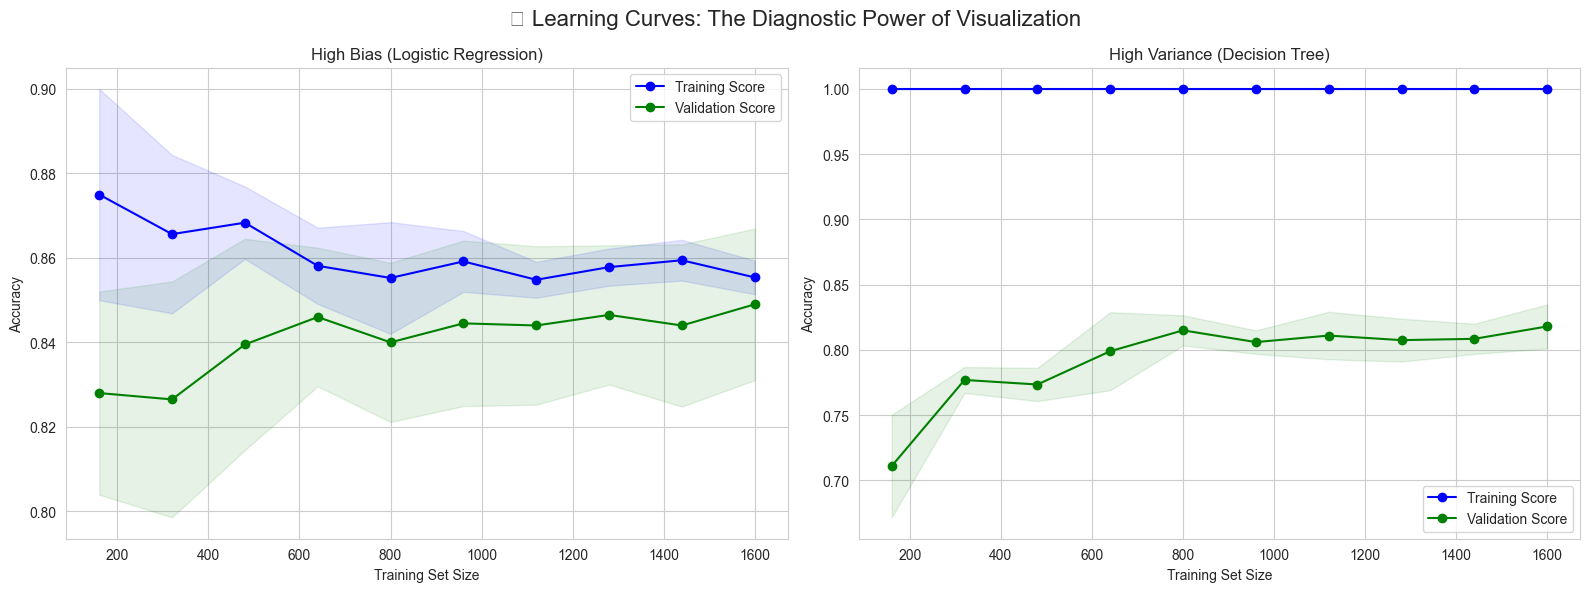

In [8]:
# Learning Curves: Diagnosing bias vs variance
X_lc, y_lc = make_classification(n_samples=2000, n_features=20, n_informative=12, 
                                 random_state=42)
train_sizes = np.linspace(0.1, 1.0, 10)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
models = {
    'High Bias (Logistic Regression)': LogisticRegression(max_iter=1000, random_state=42),
    'High Variance (Decision Tree)': DecisionTreeClassifier(max_depth=20, random_state=42)
}
for idx, (name, model) in enumerate(models.items()):
    train_sizes_abs, train_scores, test_scores = learning_curve(
        model, X_lc, y_lc, train_sizes=train_sizes, cv=5, scoring='accuracy', n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)
    axes[idx].plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Score')
    axes[idx].fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    axes[idx].plot(train_sizes_abs, test_mean, 'o-', color='green', label='Validation Score')
    axes[idx].fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend()
    axes[idx].grid(True)
plt.suptitle('📈 Learning Curves: The Diagnostic Power of Visualization', fontsize=16)
plt.tight_layout()
plt.show()


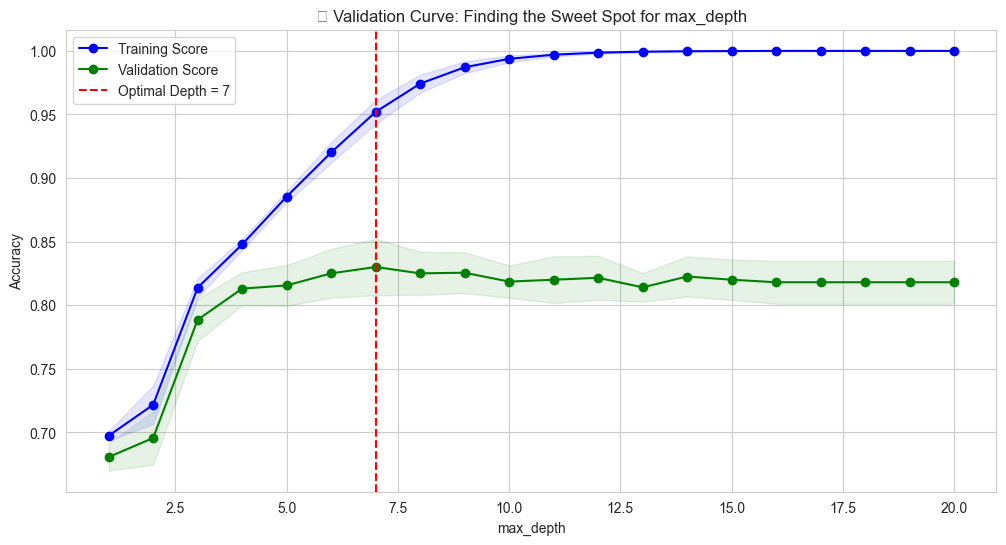

In [9]:
# Validation Curves: Tuning hyperparameters
param_range = np.arange(1, 21)
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42), X_lc, y_lc, 
    param_name='max_depth', param_range=param_range, cv=5, scoring='accuracy', n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)
plt.figure(figsize=(12, 6))
plt.plot(param_range, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(param_range, test_mean, 'o-', color='green', label='Validation Score')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
plt.axvline(param_range[np.argmax(test_mean)], color='red', linestyle='--', 
            label=f'Optimal Depth = {param_range[np.argmax(test_mean)]}')
plt.title('🔄 Validation Curve: Finding the Sweet Spot for max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## 4. Introduction to Ensemble Methods
Ensemble methods combine multiple models to achieve better predictive performance than any single model could achieve alone. The core idea is simple: **wisdom of crowds.** 🧠
- **Bagging**: Reduces variance (e.g., Random Forest)
- **Boosting**: Reduces bias (e.g., Gradient Boosting)
- **Voting/Stacking**: Combines different algorithms


In [10]:
# Conceptual overview with a simple ensemble
X_ens, y_ens = make_classification(n_samples=1000, n_features=10, n_informative=8, 
                                   random_state=42)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_ens, y_ens, test_size=0.3, random_state=42
)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}
individual_scores = {}
for name, model in models.items():
    model.fit(X_train_e, y_train_e)
    score = accuracy_score(y_test_e, model.predict(X_test_e))
    individual_scores[name] = score
    print(f"{name:20s}: {score:.4f}")


Logistic Regression : 0.7167
Random Forest       : 0.8867
SVM                 : 0.9133
KNN                 : 0.8967


## 5. Voting Ensembles (Hard & Soft Voting)
Voting is the simplest ensemble technique. Models vote on predictions — either by majority class (hard) or averaged probabilities (soft). Soft voting typically performs better when models are well-calibrated. 🗳️


In [11]:
# Hard Voting Ensemble
hard_voting = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                ('svc', SVC(random_state=42))],
    voting='hard'
)
hard_voting.fit(X_train_e, y_train_e)
hard_score = accuracy_score(y_test_e, hard_voting.predict(X_test_e))
print(f"Hard Voting Accuracy: {hard_score:.4f}")


Hard Voting Accuracy: 0.8967


In [12]:
# Soft Voting Ensemble (requires probability=True)
soft_voting = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                ('svc', SVC(probability=True, random_state=42))],
    voting='soft'
)
soft_voting.fit(X_train_e, y_train_e)
soft_score = accuracy_score(y_test_e, soft_voting.predict(X_test_e))
print(f"Soft Voting Accuracy: {soft_score:.4f}")
print(f"\n💡 Soft voting leverages confidence levels, usually outperforming hard voting!")


Soft Voting Accuracy: 0.8900

💡 Soft voting leverages confidence levels, usually outperforming hard voting!


## 6. Stacking & Blending Techniques
Stacking (Stacked Generalization) trains a meta-learner to optimally combine base model predictions. It's more sophisticated than voting and often yields superior results. Blending is similar but uses a holdout validation set. 🏗️


In [14]:
# Stacking Classifier with multiple base estimators
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
]
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)
stacking_clf.fit(X_train_e, y_train_e)
stacking_score = accuracy_score(y_test_e, stacking_clf.predict(X_test_e))
print(f"Stacking Ensemble Accuracy: {stacking_score:.4f}")


Stacking Ensemble Accuracy: 0.9000


In [16]:
# Blending (manual implementation using holdout set)
X_train_blend, X_holdout, y_train_blend, y_holdout = train_test_split(
    X_train_e, y_train_e, test_size=0.2, random_state=42
)
# Train base models
base_models = [
    RandomForestClassifier(n_estimators=100, random_state=42),
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    LogisticRegression(max_iter=1000, random_state=42)
]
meta_features = np.zeros((X_holdout.shape[0], len(base_models)))
for i, model in enumerate(base_models):
    model.fit(X_train_blend, y_train_blend)
    meta_features[:, i] = model.predict_proba(X_holdout)[:, 1]
# Train meta-learner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)
meta_learner.fit(meta_features, y_holdout)
# Predict on test set
test_meta = np.zeros((X_test_e.shape[0], len(base_models)))
for i, model in enumerate(base_models):
    test_meta[:, i] = model.predict_proba(X_test_e)[:, 1]
blend_pred = meta_learner.predict(test_meta)
blend_score = accuracy_score(y_test_e, blend_pred)
print(f"Blending Ensemble Accuracy: {blend_score:.4f}")


Blending Ensemble Accuracy: 0.8867


## 7. Applying Ensembling to Titanic Dataset (Classification)
Let's put theory into practice with the classic Titanic survival prediction problem. We'll compare single models against our ensemble methods. 🚢


In [17]:
# Load and preprocess Titanic dataset
titanic = sns.load_dataset('titanic')
titanic = titanic[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()
titanic.dropna(inplace=True)
titanic['sex'] = LabelEncoder().fit_transform(titanic['sex'])
titanic['embarked'] = LabelEncoder().fit_transform(titanic['embarked'])
X_titanic = titanic.drop('survived', axis=1)
y_titanic = titanic['survived']
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic
)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(X_train_t)
X_test_t = scaler.transform(X_test_t)
print(f"Titanic dataset: {X_titanic.shape[0]} samples, {X_titanic.shape[1]} features")


Titanic dataset: 712 samples, 7 features


In [18]:
# Single models on Titanic
titanic_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}
titanic_results = {}
for name, model in titanic_models.items():
    model.fit(X_train_t, y_train_t)
    pred = model.predict(X_test_t)
    acc = accuracy_score(y_test_t, pred)
    titanic_results[name] = acc
    print(f"{name:20s}: Accuracy = {acc:.4f}")


Logistic Regression : Accuracy = 0.7902
Random Forest       : Accuracy = 0.7902
Gradient Boosting   : Accuracy = 0.7902
SVM                 : Accuracy = 0.8252


In [19]:
# Ensemble models on Titanic
voting_clf = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
                ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42)),
                ('svc', SVC(probability=True, random_state=42))],
    voting='soft'
)
stacking_clf_titanic = StackingClassifier(
    estimators=[('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
                ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42)),
                ('svc', SVC(probability=True, random_state=42))],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5, stack_method='predict_proba'
)
voting_clf.fit(X_train_t, y_train_t)
stacking_clf_titanic.fit(X_train_t, y_train_t)
titanic_results['Soft Voting'] = accuracy_score(y_test_t, voting_clf.predict(X_test_t))
titanic_results['Stacking'] = accuracy_score(y_test_t, stacking_clf_titanic.predict(X_test_t))
print(f"Soft Voting          : Accuracy = {titanic_results['Soft Voting']:.4f}")
print(f"Stacking             : Accuracy = {titanic_results['Stacking']:.4f}")


Soft Voting          : Accuracy = 0.7972
Stacking             : Accuracy = 0.7972


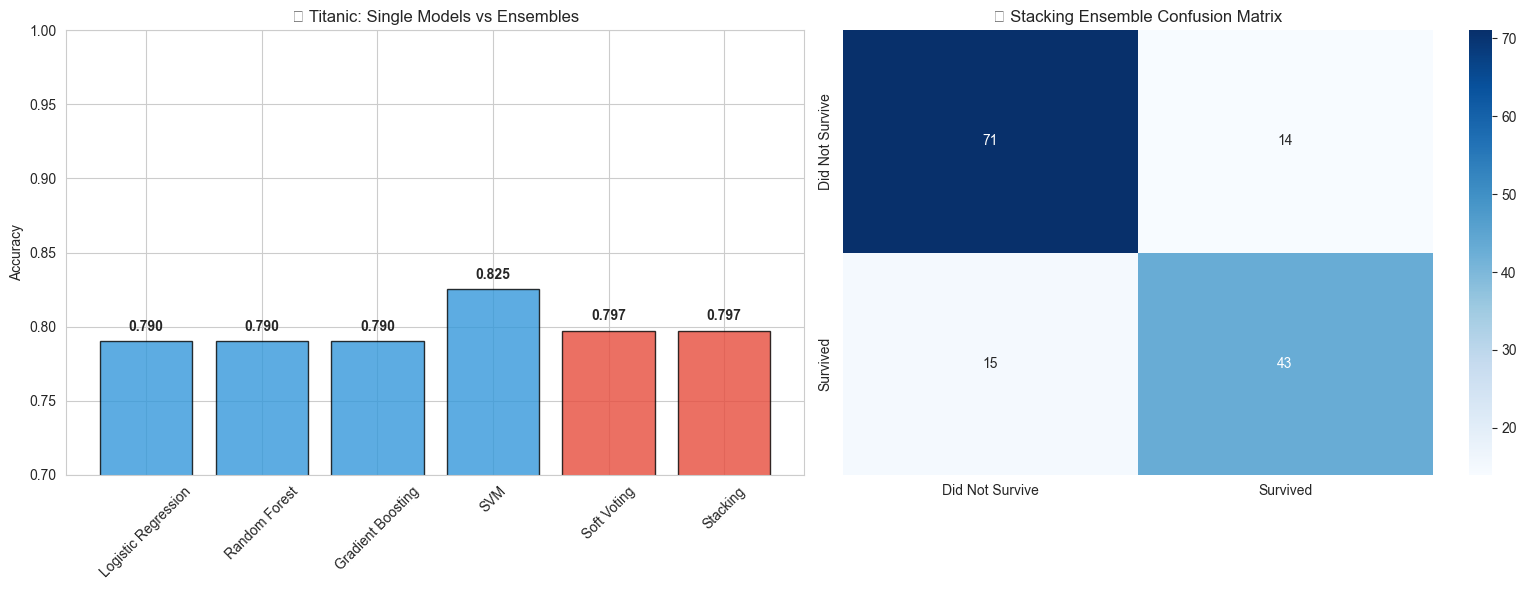

In [20]:
# Visualize Titanic results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Bar chart comparison
names = list(titanic_results.keys())
scores = list(titanic_results.values())
colors = ['#3498db' if 'Voting' not in n and 'Stacking' not in n else '#e74c3c' for n in names]
bars = axes[0].bar(names, scores, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('📊 Titanic: Single Models vs Ensembles')
axes[0].tick_params(axis='x', rotation=45)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
# Confusion matrix for best ensemble
cm_titanic = confusion_matrix(y_test_t, stacking_clf_titanic.predict(X_test_t))
sns.heatmap(cm_titanic, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
axes[1].set_title('🧩 Stacking Ensemble Confusion Matrix')
plt.tight_layout()
plt.show()


## 8. Applying Ensembling to House Prices Dataset (Regression)
Ensembling isn't just for classification! Let's apply Stacking to a regression problem using the California Housing dataset. 🏠


In [21]:
# Load California Housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X_house = pd.DataFrame(housing.data, columns=housing.feature_names)
y_house = housing.target
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)
scaler_h = StandardScaler()
X_train_h = scaler_h.fit_transform(X_train_h)
X_test_h = scaler_h.transform(X_test_h)
print(f"California Housing: {X_house.shape[0]} samples, {X_house.shape[1]} features")


California Housing: 20640 samples, 8 features


In [22]:
# Single regression models
from sklearn.ensemble import StackingRegressor
house_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge': Ridge(alpha=1.0)
}
house_results = {}
for name, model in house_models.items():
    model.fit(X_train_h, y_train_h)
    pred = model.predict(X_test_h)
    rmse = np.sqrt(mean_squared_error(y_test_h, pred))
    r2 = r2_score(y_test_h, pred)
    house_results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name:20s}: RMSE = {rmse:.4f}, R² = {r2:.4f}")


Random Forest       : RMSE = 0.5051, R² = 0.8053
Gradient Boosting   : RMSE = 0.5422, R² = 0.7756
Ridge               : RMSE = 0.7456, R² = 0.5758


In [23]:
# Stacking Regressor
stacking_reg = StackingRegressor(
    estimators=[('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
                ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
                ('ridge', Ridge(alpha=1.0))],
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
stacking_reg.fit(X_train_h, y_train_h)
pred_stack = stacking_reg.predict(X_test_h)
house_results['Stacking'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_h, pred_stack)),
    'R2': r2_score(y_test_h, pred_stack)
}
print(f"Stacking Regressor   : RMSE = {house_results['Stacking']['RMSE']:.4f}, R² = {house_results['Stacking']['R2']:.4f}")


Stacking Regressor   : RMSE = 0.5018, R² = 0.8079


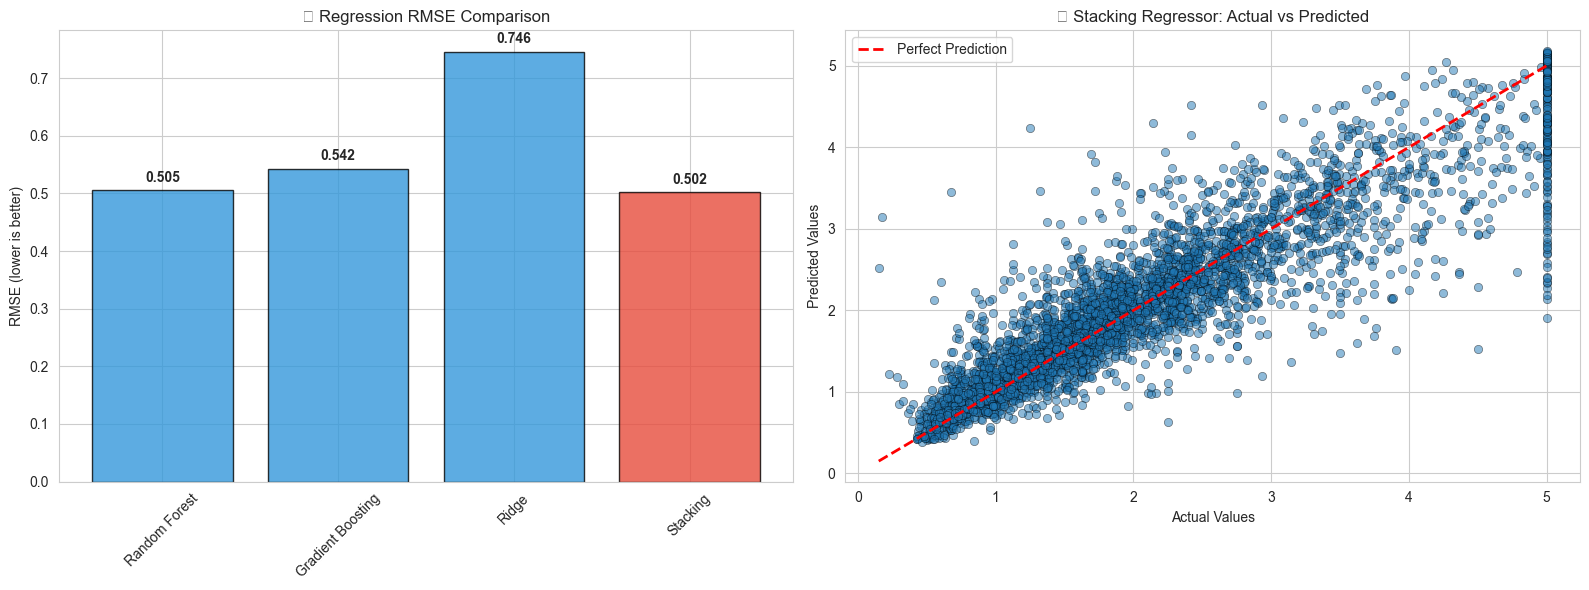

In [24]:
# Regression performance visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# RMSE comparison
names_h = list(house_results.keys())
rmse_scores = [house_results[n]['RMSE'] for n in names_h]
r2_scores = [house_results[n]['R2'] for n in names_h]
colors_h = ['#3498db' if n != 'Stacking' else '#e74c3c' for n in names_h]
bars1 = axes[0].bar(names_h, rmse_scores, color=colors_h, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('RMSE (lower is better)')
axes[0].set_title('📉 Regression RMSE Comparison')
axes[0].tick_params(axis='x', rotation=45)
for bar, score in zip(bars1, rmse_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
# Actual vs Predicted scatter
axes[1].scatter(y_test_h, pred_stack, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[1].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('🏠 Stacking Regressor: Actual vs Predicted')
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Performance Comparison: Single Models vs Ensembles
Let's create a comprehensive comparison dashboard showing the consistent improvement ensembles provide across different metrics and datasets. 📈


In [25]:
# Comprehensive comparison summary
comparison_data = {
    'Titanic (Accuracy)': {
        'Best Single Model': max([v for k, v in titanic_results.items() if k not in ['Soft Voting', 'Stacking']]),
        'Soft Voting': titanic_results['Soft Voting'],
        'Stacking': titanic_results['Stacking']
    },
    'Housing (R² Score)': {
        'Best Single Model': max([v['R2'] for k, v in house_results.items() if k != 'Stacking']),
        'Soft Voting': None,
        'Stacking': house_results['Stacking']['R2']
    }
}
print("=" * 60)
print("🏆 ENSEMBLE IMPROVEMENT SUMMARY")
print("=" * 60)
for dataset, metrics in comparison_data.items():
    print(f"\n📊 {dataset}:")
    best_single = metrics['Best Single Model']
    print(f"   Best Single Model : {best_single:.4f}")
    if metrics['Soft Voting']:
        print(f"   Soft Voting       : {metrics['Soft Voting']:.4f} (+{metrics['Soft Voting']-best_single:.4f})")
    if metrics['Stacking']:
        print(f"   Stacking          : {metrics['Stacking']:.4f} (+{metrics['Stacking']-best_single:.4f})")
print("\n✅ Ensembles consistently extract the best from each base model!")


🏆 ENSEMBLE IMPROVEMENT SUMMARY

📊 Titanic (Accuracy):
   Best Single Model : 0.8252
   Soft Voting       : 0.7972 (+-0.0280)
   Stacking          : 0.7972 (+-0.0280)

📊 Housing (R² Score):
   Best Single Model : 0.8053
   Stacking          : 0.8079 (+0.0026)

✅ Ensembles consistently extract the best from each base model!


## 10. Best Practices for Ensembling in Real Projects
Before we wrap up, here are battle-tested guidelines for deploying ensembles in production: 💡
- **Diversity is Key**: Combine models with different architectures and biases
- **Avoid Correlated Errors**: If all models make the same mistakes, ensembling won't help
- **Calibrate Probabilities**: Especially important for soft voting
- **Monitor Inference Cost**: Ensembles are slower; consider latency requirements
- **Use Cross-Validation for Stacking**: Never let base models see meta-learner training data
- **Start Simple**: Begin with Voting, then graduate to Stacking
- **Feature Engineering Still Matters**: Ensembles amplify good features, they don't create them


## 🛠️ Hands-On Exercises

### Exercise 1: Implement Stratified K-Fold CV
Implement StratifiedKFold with 10 splits on an imbalanced dataset and compare mean accuracy with standard K-Fold.


### Exercise 2: Repeated Cross-Validation
Use RepeatedStratifiedKFold (5 splits, 5 repeats) and calculate the standard deviation of scores to understand score stability.


### Exercise 3: Plot Learning Curves
Generate learning curves for a RandomForestClassifier with varying `n_estimators` (10, 50, 100, 200) and interpret the bias-variance tradeoff.


### Exercise 4: Validation Curve for Regularization
Plot a validation curve for `C` parameter in LogisticRegression (range: 0.001 to 100) and identify the optimal value.


### Exercise 5: Build a Hard Voting Ensemble
Create a VotingClassifier with 3 different algorithms (not used in the lesson) using hard voting. Evaluate on the Titanic dataset.


### Exercise 6: Build a Soft Voting Ensemble
Convert your hard voting ensemble to soft voting. Compare the ROC-AUC scores of both approaches.


### Exercise 7: Implement Stacking with Custom Meta-Learner
Build a StackingClassifier using a GradientBoostingClassifier as the final estimator instead of LogisticRegression. Compare performance.


### Exercise 8: Manual Blending Implementation
Implement blending manually using a 70/30 split for base models and meta-learner training. Use 3 base models of your choice.


### Exercise 9: Ensemble Hyperparameter Tuning
Use GridSearchCV to tune the `weights` parameter of a VotingClassifier. Try different weight combinations for your base models.


### Exercise 10: Create a Robust Ensemble Pipeline
Build a complete pipeline that includes preprocessing (scaling, encoding), cross-validation, and a Stacking ensemble. Save the best model using joblib.


## Solutions & Best Practices (Review After Attempting)

### Exercise 1 Solution
StratifiedKFold ensures each fold has the same class proportion as the full dataset. This is crucial for imbalanced data where random splits might create folds with zero minority class samples.
```python
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
# Compare: cross_val_score(model, X, y, cv=skf) vs cross_val_score(model, X, y, cv=kf)
```
**Real-world tip**: Always use StratifiedKFold for classification, especially with imbalanced datasets like fraud detection or medical diagnosis.

### Exercise 2 Solution
Repeated CV provides a more robust estimate by averaging across multiple shuffles. Look for low standard deviation — high variance suggests your model is sensitive to data splits.
```python
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
scores = cross_val_score(model, X, y, cv=rskf)
print(f"Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")
```
**Real-world tip**: Use repeated CV for final model evaluation before deployment, but stick to simple CV during hyperparameter tuning to save time.

### Exercise 3 Solution
As `n_estimators` increases, training score stays high while validation score converges. If the gap is large, you have high variance (overfitting). If both are low, you have high bias.
**Real-world tip**: More trees in Random Forest rarely hurt (diminishing returns after ~200), but they increase inference latency.

### Exercise 4 Solution
Small `C` = strong regularization (high bias, low variance). Large `C` = weak regularization (low bias, high variance). The optimal `C` balances both.
**Real-world tip**: Use `np.logspace(-3, 2, 10)` for `C` search — regularization effects are logarithmic.

### Exercise 5 Solution
Hard voting works best when models have similar performance. If one model is significantly worse, it can drag down the ensemble.
**Real-world tip**: Try combining tree-based models with linear models for maximum diversity.

### Exercise 6 Solution
Soft voting requires `probability=True` for SVC. It generally outperforms hard voting because it considers prediction confidence, not just the final class label.
**Real-world tip**: Calibrate probabilities using `CalibratedClassifierCV` if using SVM or naive Bayes as base estimators.

### Exercise 7 Solution
Tree-based meta-learners can capture non-linear interactions between base model predictions. However, they might overfit if you have few base models.
**Real-world tip**: Start with linear meta-learners (LogisticRegression/Ridge) — they're robust and interpretable.

### Exercise 8 Solution
The key to blending is ensuring base models never see the holdout set used to train the meta-learner. This prevents information leakage.
**Real-world tip**: Blending is faster to implement than stacking but uses less data for base model training. Use stacking when data is scarce.

### Exercise 9 Solution
Weights allow you to give more importance to stronger base models. Start with equal weights, then increase weights for models with higher individual validation scores.
```python
param_grid = {'weights': [[1,1,1], [2,1,1], [1,2,1], [1,1,2], [2,2,1]]}
```
**Real-world tip**: Weight tuning is especially useful when you have one very strong model and several weaker but diverse models.

### Exercise 10 Solution
A robust pipeline encapsulates all preprocessing and modeling steps, ensuring consistent transformations between training and inference.
```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib
# Build pipeline, fit, then joblib.dump(pipeline, 'ensemble_pipeline.pkl')
```
**Real-world tip**: Always save the entire pipeline, not just the model. This prevents training-serving skew when preprocessing steps change.
